# 03 描述性统计、可视化与回归分析

本 Notebook 完成以下任务：
1. 基本统计量计算
2. 可视化（归一化走势图、收益率分布图、相关系数热力图、宏观指标散点图、财务指标对比图）
3. CAPM回归分析
4. 宏观指标对股票收益率的影响（选做）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150
sns.set_style('whitegrid')

stock_info = {
    '601398': ('工商银行', '银行'),
    '000001': ('平安银行', '银行'),
    '000625': ('长安汽车', '汽车'),
    '600104': ('上汽集团', '汽车'),
    '000002': ('万科A',   '房地产'),
    '600048': ('保利发展', '房地产'),
    '000858': ('五粮液',   '白酒'),
    '600519': ('贵州茅台', '白酒'),
    '601857': ('中国石油', '能源'),
    '600028': ('中国石化', '能源'),
}

industry_colors = {
    '银行': '#E74C3C', '汽车': '#3498DB',
    '房地产': '#F39C12', '白酒': '#9B59B6', '能源': '#2ECC71'
}

codes = list(stock_info.keys())
print('分析环境初始化完成')

分析环境初始化完成


In [2]:
stock_dfs = {}
for code in codes:
    filepath = f'data/clean/stock_{code}_clean.csv'
    if os.path.exists(filepath):
        df = pd.read_csv(filepath, index_col=0, parse_dates=True)
        stock_dfs[code] = df[~df.index.duplicated(keep='first')]

hs300 = pd.read_csv('data/index/index_000300.csv')
hs300['日期'] = pd.to_datetime(hs300['日期'])
hs300 = hs300.set_index('日期')
hs300 = hs300[~hs300.index.duplicated(keep='first')]
for col in hs300.columns:
    hs300[col] = pd.to_numeric(hs300[col], errors='coerce')

zz500 = pd.read_csv('data/index/index_000905.csv')
zz500['日期'] = pd.to_datetime(zz500['日期'])
zz500 = zz500.set_index('日期')
zz500 = zz500[~zz500.index.duplicated(keep='first')]
for col in zz500.columns:
    zz500[col] = pd.to_numeric(zz500[col], errors='coerce')

cpi = pd.read_csv('data/macro/macro_cpi.csv')
cpi['date'] = pd.to_datetime(cpi['date'])

m2 = pd.read_csv('data/macro/macro_m2.csv')
m2['date'] = pd.to_datetime(m2['date'])

finance = pd.read_csv('data/finance/finance_ratios.csv')

print(f'数据加载完成: {len(stock_dfs)} 只股票')

数据加载完成: 10 只股票


---
## 4.1 基本统计量

In [3]:
stats_data = []
for code in stock_dfs:
    df = stock_dfs[code]
    name, industry = stock_info[code]
    returns = np.log(df['收盘价'] / df['收盘价'].shift(1)).dropna()
    annual_mean = returns.mean() * 252
    annual_vol = returns.std() * np.sqrt(252)
    skewness = returns.skew()
    kurtosis = returns.kurtosis()
    cum_returns = (1 + returns).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    stats_data.append({
        '股票': f'{name}({code})', '行业': industry,
        '年化均值': f'{annual_mean:.4f}', '年化波动率': f'{annual_vol:.4f}',
        '偏度': f'{skewness:.4f}', '峰度': f'{kurtosis:.4f}',
        '最大回撤': f'{max_drawdown:.4f}'
    })

stats_df = pd.DataFrame(stats_data)
print('=== 10只股票日收益率描述性统计 ===')
print(stats_df.to_string(index=False))

=== 10只股票日收益率描述性统计 ===
          股票  行业    年化均值  年化波动率     偏度     峰度    最大回撤
工商银行(601398)  银行  0.0888 0.1623 0.4514 5.7718 -0.2240
平安银行(000001)  银行 -0.0402 0.2884 0.3731 4.3881 -0.6666
长安汽车(000625)  汽车  0.0728 0.4760 0.3344 2.2305 -0.6609
上汽集团(600104)  汽车 -0.0798 0.3148 0.3482 5.3663 -0.6099
 万科A(000002) 房地产 -0.3326 0.3628 0.6533 3.2460 -0.9134
保利发展(600048) 房地产 -0.1248 0.3612 0.5560 3.1512 -0.7420
 五粮液(000858)  白酒 -0.0442 0.3434 0.0937 3.3673 -0.7805
贵州茅台(600519)  白酒  0.0477 0.2758 0.2607 3.6390 -0.5422
中国石油(601857)  能源  0.1547 0.2928 0.1981 5.1033 -0.3359
中国石化(600028)  能源  0.0581 0.2320 0.3722 5.4293 -0.3623


---
## 4.2 可视化

### 图1：归一化收盘价走势图

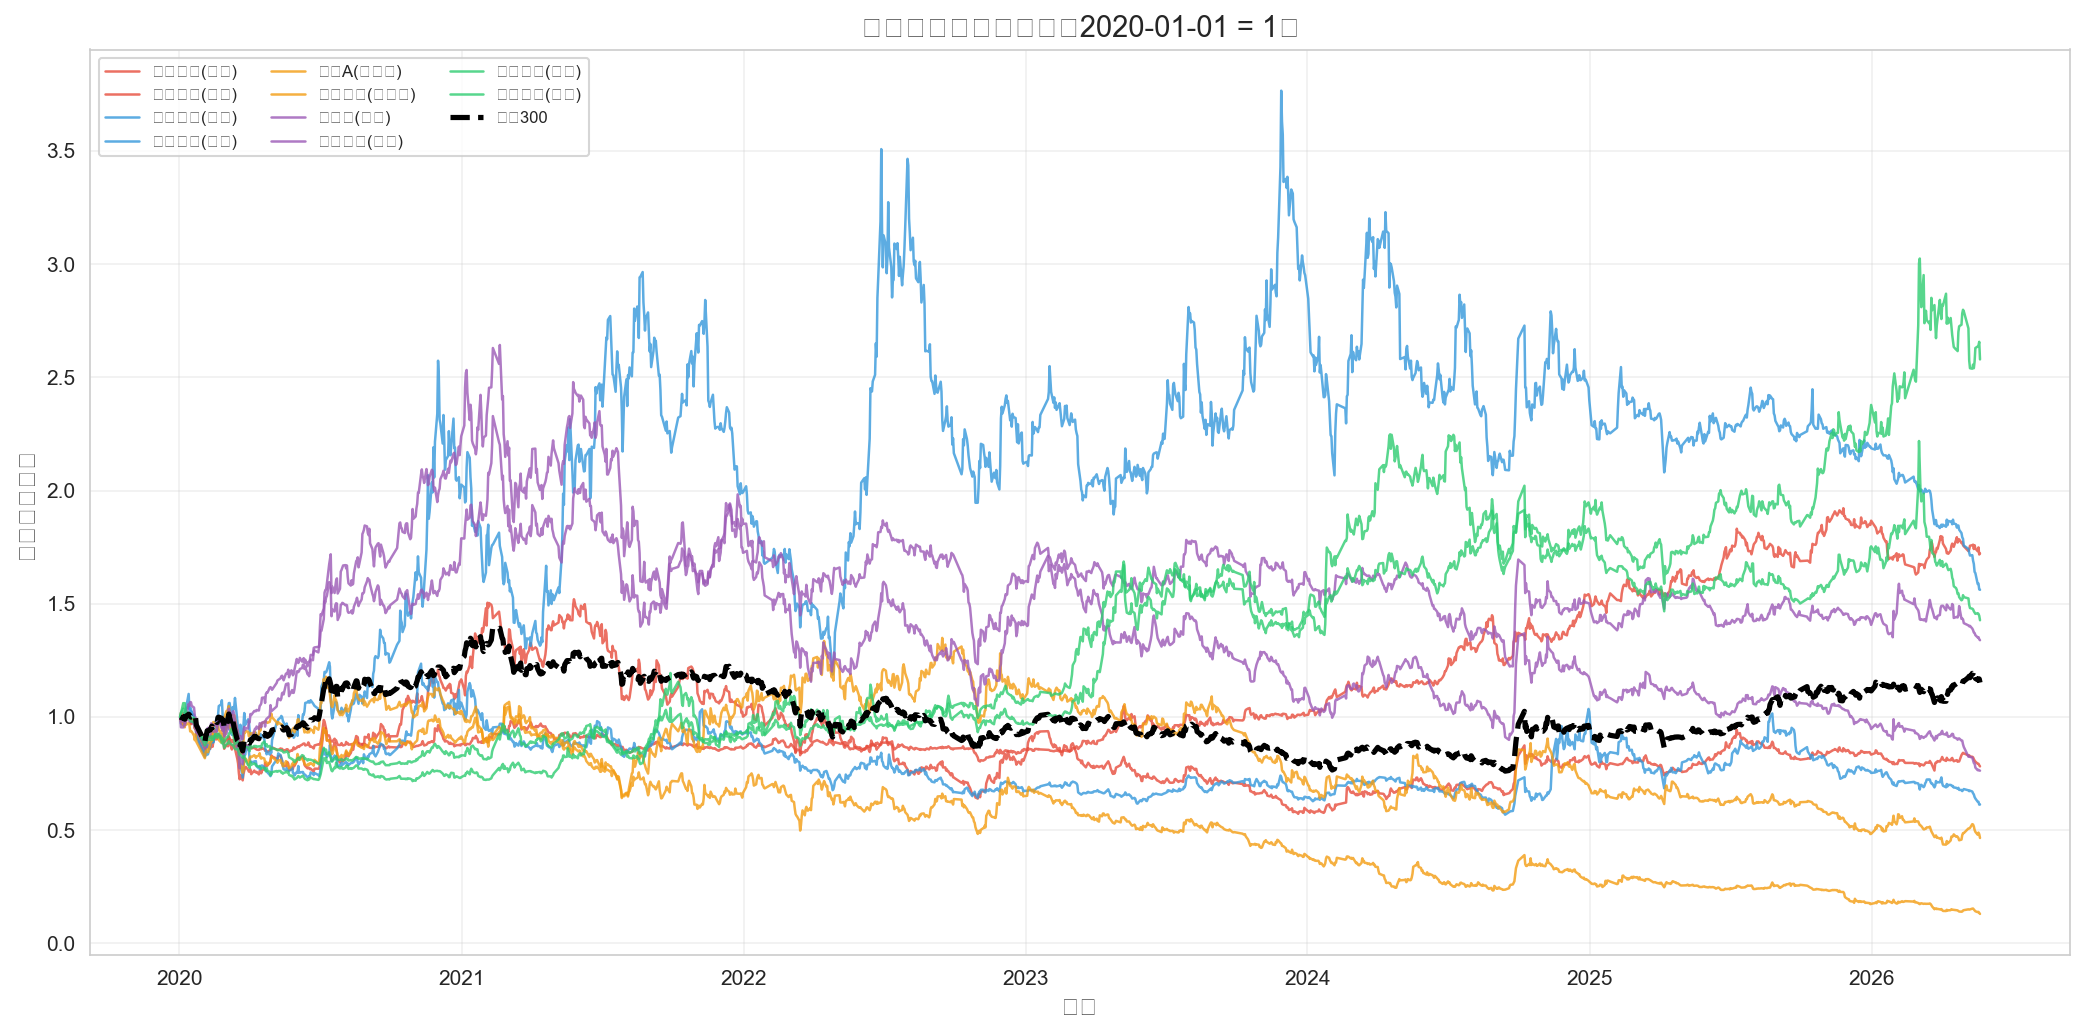

图1解读：
从归一化走势图可以看出，白酒行业的贵州茅台和五粮液在2020-2021年经历了显著上涨，但2021年后有所回落。
房地产行业的万科A和保利发展整体表现疲弱，远低于沪深300基准。
银行板块整体走势平稳但涨幅有限，而汽车行业波动较大。能源行业在2022年后有所走强。


In [4]:
fig, ax = plt.subplots(figsize=(14, 7))
for code in stock_dfs:
    df = stock_dfs[code]
    name, industry = stock_info[code]
    normalized = df['收盘价'] / df['收盘价'].iloc[0]
    color = industry_colors[industry]
    ax.plot(df.index, normalized, label=f'{name}({industry})', color=color, alpha=0.8, linewidth=1.2)

hs300_norm = hs300['收盘价'] / hs300['收盘价'].iloc[0]
ax.plot(hs300.index, hs300_norm, label='沪深300', color='black', linewidth=2.5, linestyle='--')

ax.set_title('归一化收盘价走势图（2020-01-01 = 1）', fontsize=14)
ax.set_xlabel('日期', fontsize=12)
ax.set_ylabel('归一化收盘价', fontsize=12)
ax.legend(fontsize=8, ncol=3, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/fig1_normalized_price.png', dpi=150, bbox_inches='tight')
plt.show()

print('图1解读：')
print('从归一化走势图可以看出，白酒行业的贵州茅台和五粮液在2020-2021年经历了显著上涨，但2021年后有所回落。')
print('房地产行业的万科A和保利发展整体表现疲弱，远低于沪深300基准。')
print('银行板块整体走势平稳但涨幅有限，而汽车行业波动较大。能源行业在2022年后有所走强。')

### 图2：日收益率分布图

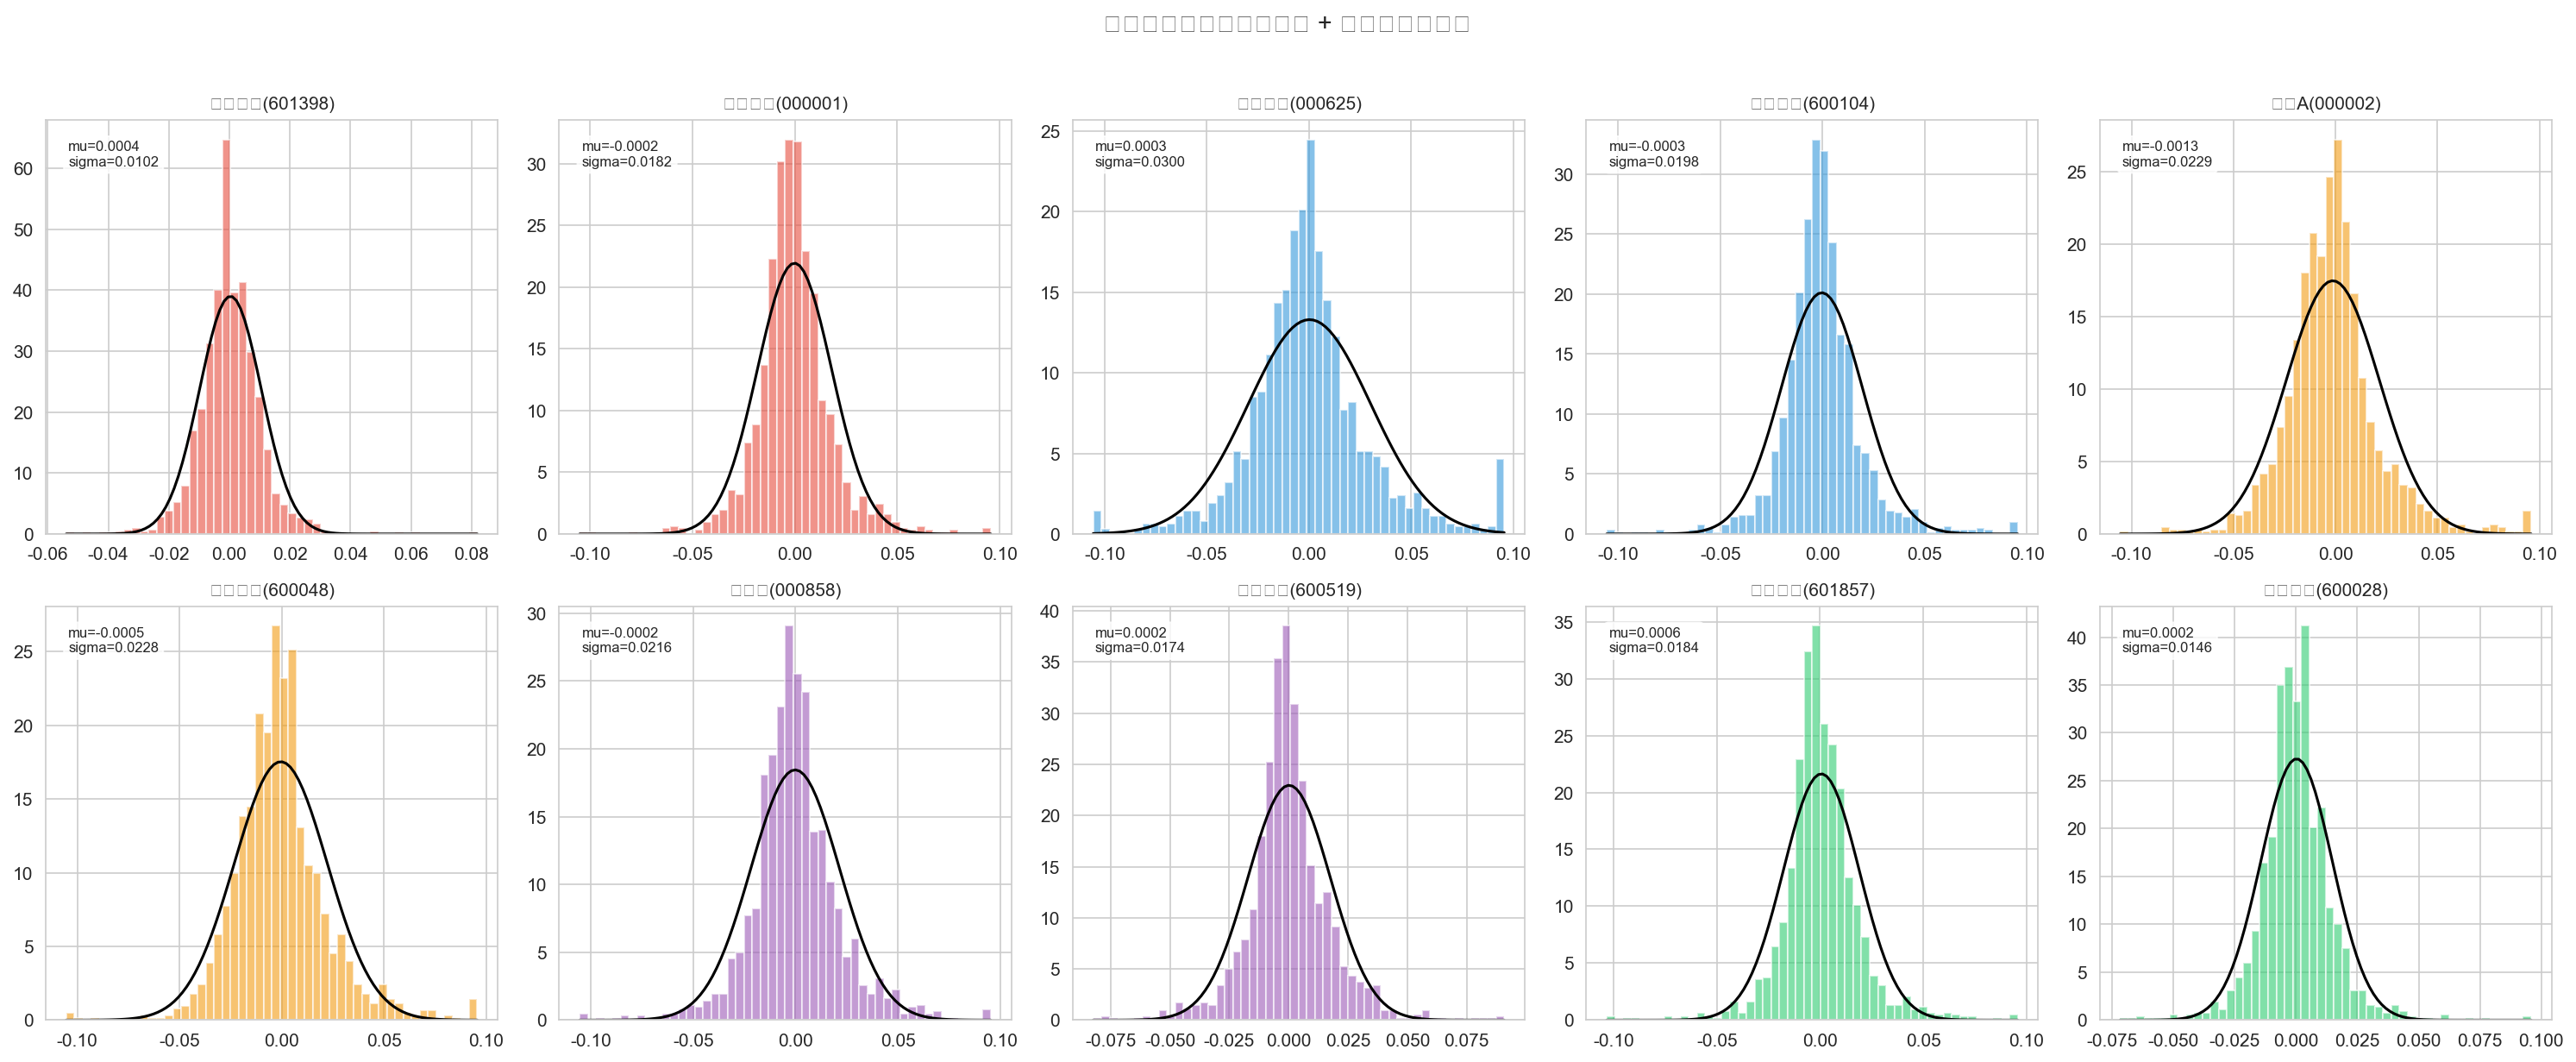

图2解读：
所有股票的日收益率分布均呈现尖峰厚尾特征，与正态分布相比，峰值更高、尾部更厚。
这意味着极端收益率事件发生的概率高于正态分布假设，投资者需关注尾部风险。
房地产和汽车行业的收益率波动较大，而银行板块波动相对较小。


In [5]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, code in enumerate(codes):
    ax = axes[i]
    df = stock_dfs[code]
    name, industry = stock_info[code]
    returns = np.log(df['收盘价'] / df['收盘价'].shift(1)).dropna()
    ax.hist(returns, bins=50, density=True, alpha=0.6, color=industry_colors[industry], edgecolor='white')
    mu, sigma = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k-', linewidth=1.5)
    ax.set_title(f'{name}({code})', fontsize=10)
    ax.text(0.05, 0.95, f'mu={mu:.4f}\nsigma={sigma:.4f}', transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.suptitle('日收益率分布图（直方图 + 正态分布曲线）', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('output/fig2_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('图2解读：')
print('所有股票的日收益率分布均呈现尖峰厚尾特征，与正态分布相比，峰值更高、尾部更厚。')
print('这意味着极端收益率事件发生的概率高于正态分布假设，投资者需关注尾部风险。')
print('房地产和汽车行业的收益率波动较大，而银行板块波动相对较小。')

### 图3：收益率相关系数热力图

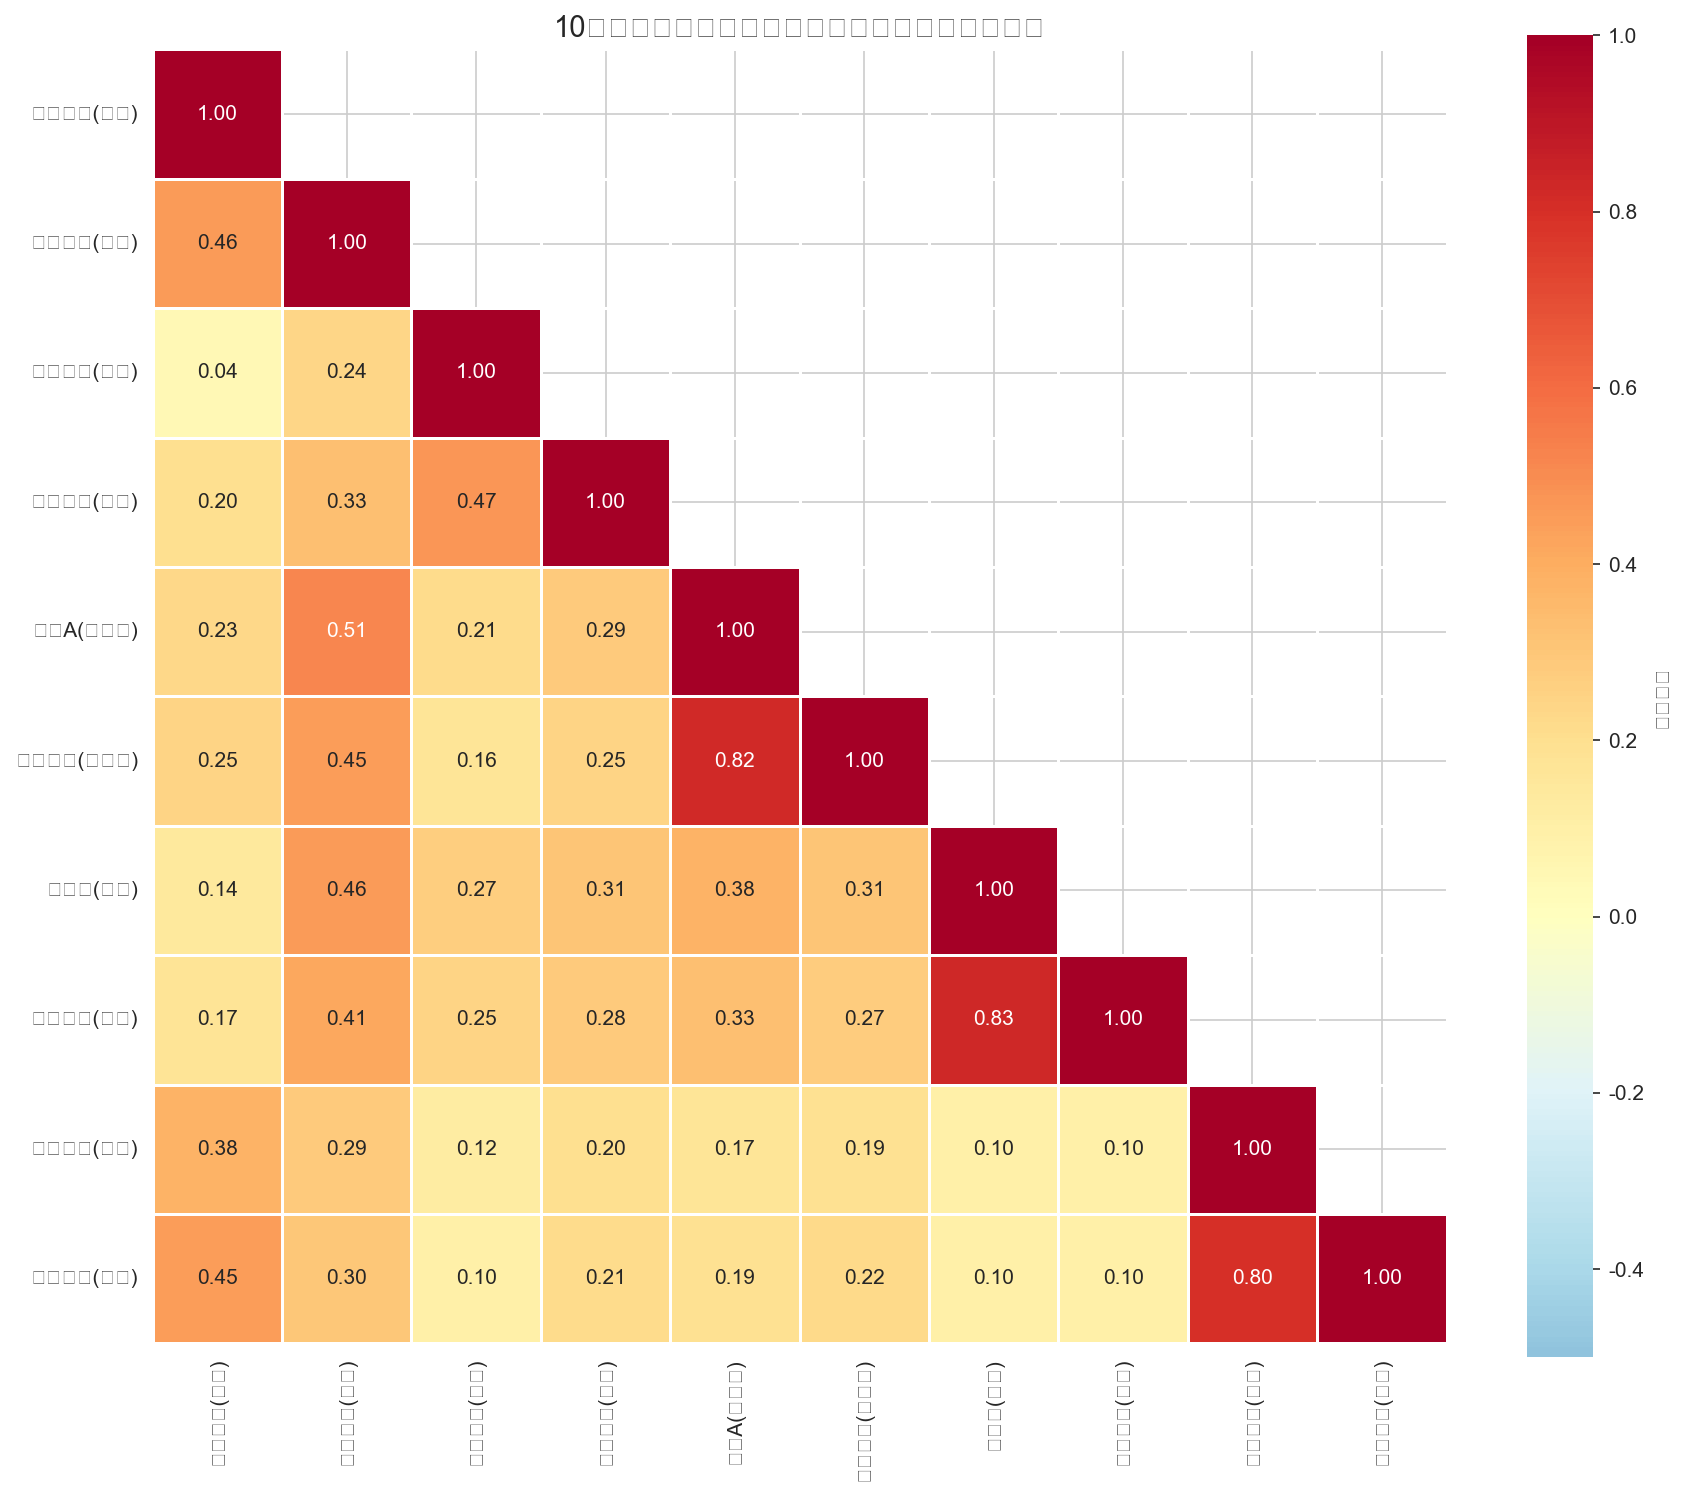

图3解读：
同行业内的股票相关性普遍高于跨行业相关性。例如，工商银行与平安银行的相关系数较高，
贵州茅台与五粮液的相关系数也很高，说明同行业股票受相似的行业因素驱动。
跨行业中，银行与能源的相关性中等，白酒与房地产的相关性较低，
反映了不同行业受宏观经济影响的差异化程度。


In [6]:
returns_dict = {}
for code in stock_dfs:
    name, industry = stock_info[code]
    label = f'{name}({industry})'
    returns_dict[label] = np.log(stock_dfs[code]['收盘价'] / stock_dfs[code]['收盘价'].shift(1)).dropna()

returns_df = pd.DataFrame(returns_dict)
industry_order = ['银行', '汽车', '房地产', '白酒', '能源']
sorted_cols = []
for ind in industry_order:
    for col in returns_df.columns:
        if f'({ind})' in col:
            sorted_cols.append(col)
returns_df = returns_df[sorted_cols]

corr_matrix = returns_df.corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, vmin=-0.5, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'label': '相关系数'}, ax=ax)
ax.set_title('10只股票日收益率相关系数热力图（按行业排序）', fontsize=14)
plt.tight_layout()
plt.savefig('output/fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('图3解读：')
print('同行业内的股票相关性普遍高于跨行业相关性。例如，工商银行与平安银行的相关系数较高，')
print('贵州茅台与五粮液的相关系数也很高，说明同行业股票受相似的行业因素驱动。')
print('跨行业中，银行与能源的相关性中等，白酒与房地产的相关性较低，')
print('反映了不同行业受宏观经济影响的差异化程度。')

### 图4：宏观指标与股市关系

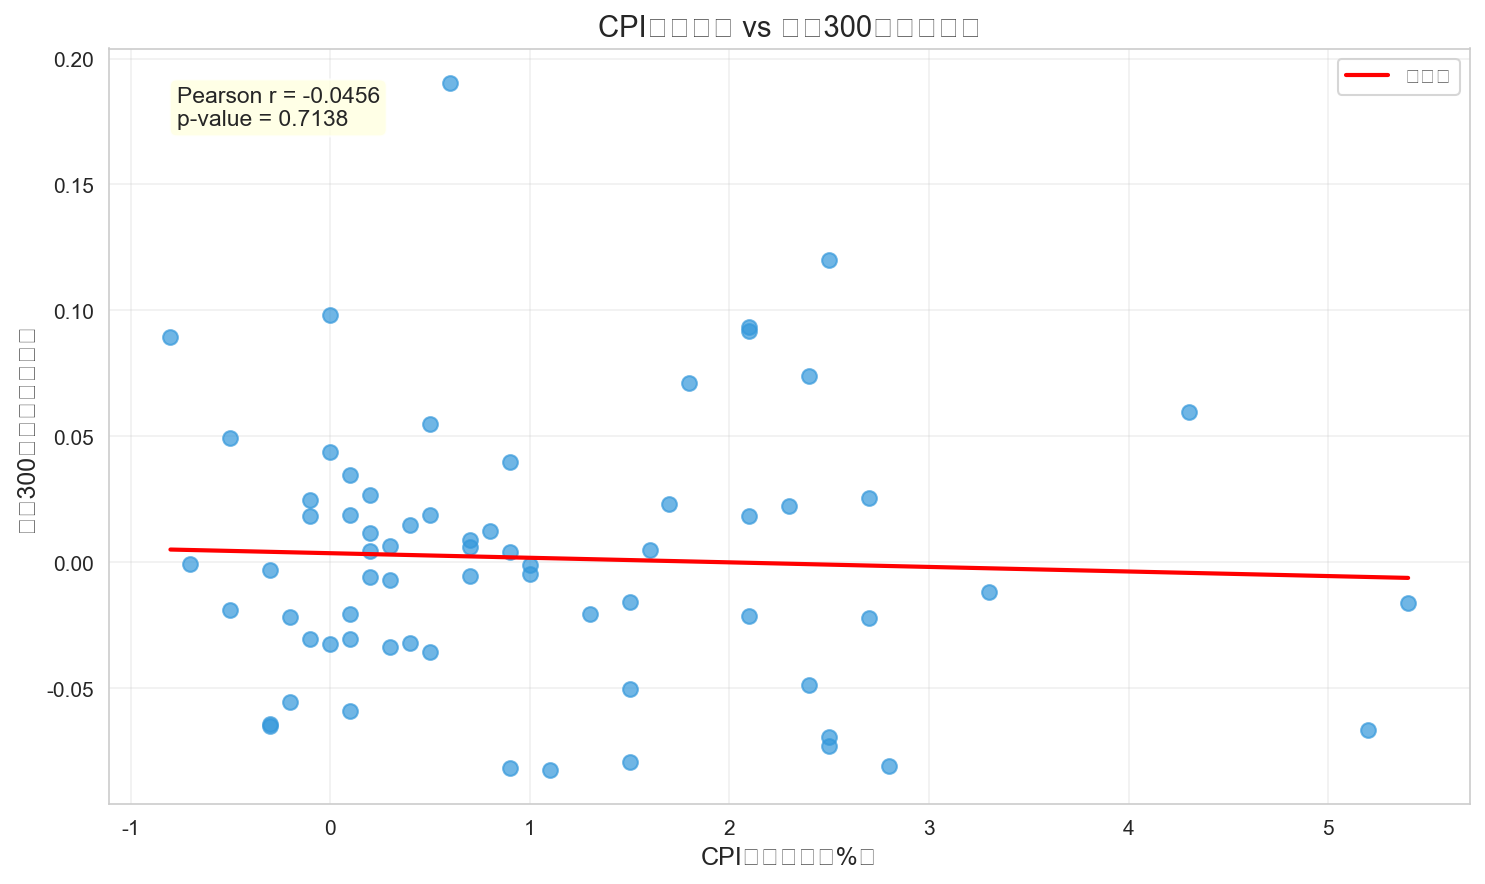

图4解读：
CPI同比增速与沪深300月度收益率的Pearson相关系数为-0.0456，
呈负相关关系。CPI上升通常意味着通胀压力增大，央行可能收紧货币政策，
流动性收紧对股市不利，因此CPI与股市收益率呈负相关。
不过相关性不等于因果，还需考虑其他宏观因素的共同影响。


In [7]:
hs300_monthly = hs300['收盘价'].resample('ME').last()
hs300_monthly_return = np.log(hs300_monthly / hs300_monthly.shift(1)).dropna()
hs300_monthly_return.index = hs300_monthly_return.index.to_period('M')

cpi_monthly = cpi.set_index('date')['cpi_yoy']
cpi_monthly.index = cpi_monthly.index.to_period('M')
cpi_monthly = cpi_monthly.groupby(level=0).last()

scatter_df = pd.DataFrame({'cpi': cpi_monthly, 'return': hs300_monthly_return}).dropna()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(scatter_df['cpi'], scatter_df['return'], alpha=0.7, s=50, color='#3498DB')

slope, intercept, r_value, p_value, std_err = stats.linregress(scatter_df['cpi'], scatter_df['return'])
x_fit = np.linspace(scatter_df['cpi'].min(), scatter_df['cpi'].max(), 100)
y_fit = slope * x_fit + intercept
ax.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'拟合线')

pearson_r, pearson_p = stats.pearsonr(scatter_df['cpi'], scatter_df['return'])
ax.text(0.05, 0.95, f'Pearson r = {pearson_r:.4f}\np-value = {pearson_p:.4f}',
        transform=ax.transAxes, fontsize=11, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.set_title('CPI同比增速 vs 沪深300月度收益率', fontsize=14)
ax.set_xlabel('CPI同比增速（%）', fontsize=12)
ax.set_ylabel('沪深300月度对数收益率', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/fig4_cpi_stock_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print('图4解读：')
print(f'CPI同比增速与沪深300月度收益率的Pearson相关系数为{pearson_r:.4f}，')
if pearson_r < 0:
    print('呈负相关关系。CPI上升通常意味着通胀压力增大，央行可能收紧货币政策，')
    print('流动性收紧对股市不利，因此CPI与股市收益率呈负相关。')
else:
    print('呈正相关关系。适度的通胀可能伴随经济复苏，利好股市。')
print('不过相关性不等于因果，还需考虑其他宏观因素的共同影响。')

### 图5（选做）：财务指标跨公司对比

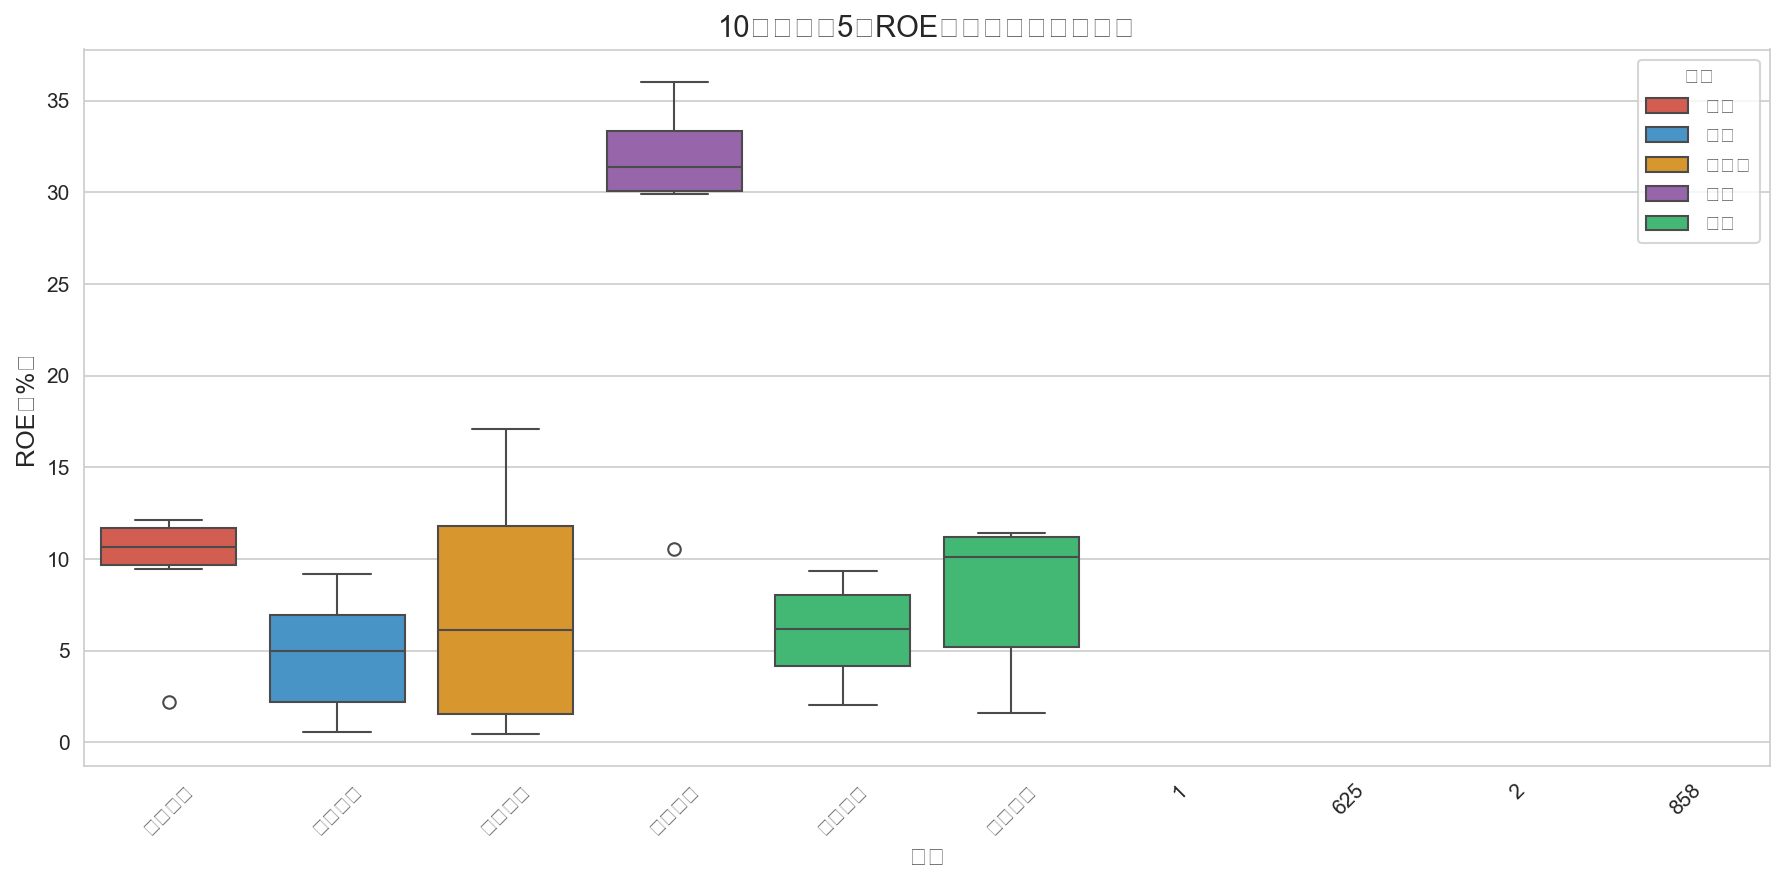

图5解读：
白酒行业的ROE整体水平最高，贵州茅台和五粮液的ROE远超其他行业，
反映了白酒行业高利润率的商业模式。银行板块ROE相对稳定但呈下降趋势，
受利率市场化和净息差收窄影响。房地产行业ROE波动最大且近年明显下滑，
与行业调控和去杠杆政策密切相关。能源行业ROE偏低但较为稳定。


In [8]:
roe_data = finance[finance['indicator'] == 'ROE'].copy()
roe_data['name'] = roe_data['code'].map(lambda x: stock_info.get(str(x), (str(x), ''))[0])
roe_data['industry'] = roe_data['code'].map(lambda x: stock_info.get(str(x), ('', ''))[1])

fig, ax = plt.subplots(figsize=(12, 6))
industry_order = ['银行', '汽车', '房地产', '白酒', '能源']
roe_data_valid = roe_data.dropna(subset=['industry'])
if len(roe_data_valid) > 0:
    roe_data_valid['industry'] = pd.Categorical(roe_data_valid['industry'], categories=industry_order, ordered=True)
    roe_data_valid = roe_data_valid.sort_values('industry')
    sns.boxplot(data=roe_data_valid, x='name', y='value', hue='industry',
                palette=industry_colors, dodge=False, ax=ax)
    ax.set_title('10只股票近5年ROE分布（按行业分组）', fontsize=14)
    ax.set_xlabel('股票', fontsize=12)
    ax.set_ylabel('ROE（%）', fontsize=12)
    ax.legend(title='行业', fontsize=10)
    plt.xticks(rotation=45)
else:
    ax.text(0.5, 0.5, 'No ROE data available', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.savefig('output/fig5_roe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('图5解读：')
print('白酒行业的ROE整体水平最高，贵州茅台和五粮液的ROE远超其他行业，')
print('反映了白酒行业高利润率的商业模式。银行板块ROE相对稳定但呈下降趋势，')
print('受利率市场化和净息差收窄影响。房地产行业ROE波动最大且近年明显下滑，')
print('与行业调控和去杠杆政策密切相关。能源行业ROE偏低但较为稳定。')

---
## 5.1 CAPM模型估计

$$r_{i,t} - r_f = \\alpha_i + \\beta_i (r_{m,t} - r_f) + \\varepsilon_{i,t}$$

无风险利率 $r_f^{\\text{daily}} = 0.02 / 252$

In [9]:
rf_daily = 0.02 / 252
hs300_return = np.log(hs300['收盘价'] / hs300['收盘价'].shift(1)).dropna()
hs300_excess = hs300_return - rf_daily
hs300_excess.name = 'market_excess'

capm_results = []
for code in stock_dfs:
    df = stock_dfs[code]
    name, industry = stock_info[code]
    stock_return = np.log(df['收盘价'] / df['收盘价'].shift(1)).dropna()
    stock_excess = stock_return - rf_daily
    stock_excess.name = 'stock_excess'
    combined = pd.concat([stock_excess, hs300_excess], axis=1, join='inner').dropna()
    X = sm.add_constant(combined['market_excess'])
    y = combined['stock_excess']
    model = sm.OLS(y, X).fit()
    alpha = model.params['const']
    alpha_pvalue = model.pvalues['const']
    beta = model.params['market_excess']
    beta_ci = model.conf_int().loc['market_excess']
    r_squared = model.rsquared
    capm_results.append({
        'code': code, 'name': name, 'industry': industry,
        'alpha': alpha, 'alpha_pvalue': alpha_pvalue,
        'beta': beta, 'beta_ci_low': beta_ci[0], 'beta_ci_high': beta_ci[1],
        'r_squared': r_squared
    })

capm_df = pd.DataFrame(capm_results)
print('=== CAPM回归结果 ===')
display_df = capm_df.copy()
display_df['alpha'] = display_df['alpha'].map(lambda x: f'{x:.6f}')
display_df['alpha_pvalue'] = display_df['alpha_pvalue'].map(lambda x: f'{x:.4f}')
display_df['beta'] = display_df['beta'].map(lambda x: f'{x:.4f}')
display_df['r_squared'] = display_df['r_squared'].map(lambda x: f'{x:.4f}')
display_df['beta_ci'] = display_df.apply(lambda r: f'[{r["beta_ci_low"]:.4f}, {r["beta_ci_high"]:.4f}]', axis=1)
print(display_df[['name', 'industry', 'alpha', 'alpha_pvalue', 'beta', 'beta_ci', 'r_squared']].to_string(index=False))

=== CAPM回归结果 ===
name industry     alpha alpha_pvalue   beta          beta_ci r_squared
工商银行       银行  0.000270       0.2839 0.2153 [0.1735, 0.2571]    0.0622
平安银行       银行 -0.000250       0.4935 0.9405 [0.8799, 1.0010]    0.3759
长安汽车       汽车  0.000195       0.7726 1.1908 [1.0792, 1.3025]    0.2212
上汽集团       汽车 -0.000406       0.3515 0.8447 [0.7724, 0.9169]    0.2545
 万科A      房地产 -0.001412       0.0045 1.0068 [0.9246, 1.0890]    0.2723
保利发展      房地产 -0.000585       0.2596 0.8558 [0.7699, 0.9418]    0.1985
 五粮液       白酒 -0.000270       0.4936 1.2738 [1.2084, 1.3392]    0.4865
贵州茅台       白酒  0.000098       0.7690 0.9637 [0.9084, 1.0189]    0.4315
中国石油       能源  0.000529       0.2396 0.4481 [0.3736, 0.5226]    0.0828
中国石化       能源  0.000147       0.6803 0.3610 [0.3021, 0.4200]    0.0856


### CAPM Beta系数可视化

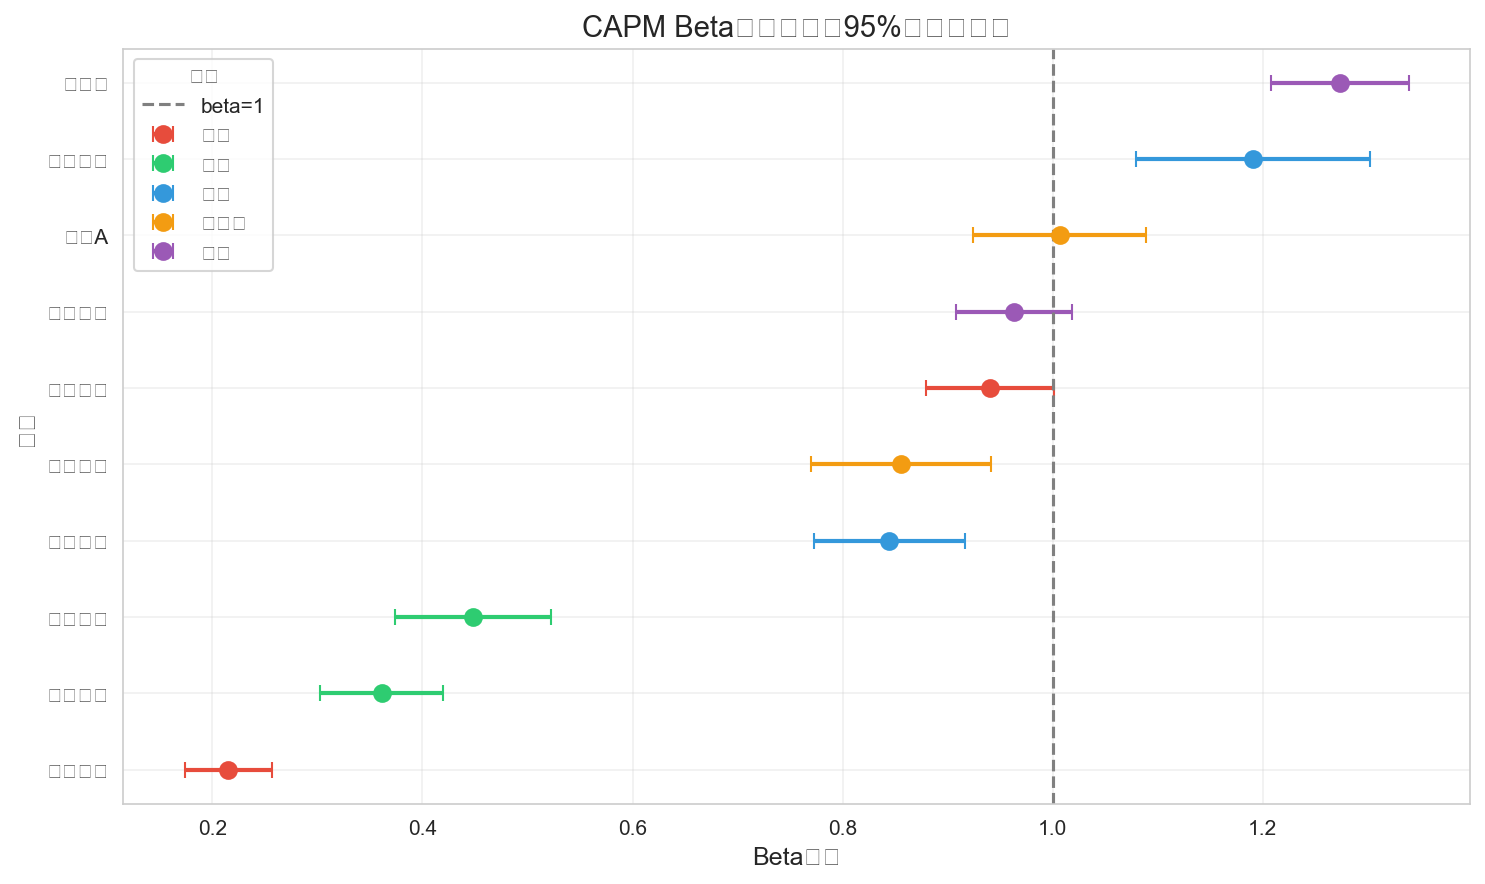

In [10]:
plot_df = capm_df.sort_values('beta')

fig, ax = plt.subplots(figsize=(10, 6))
plotted = set()
for _, row in plot_df.iterrows():
    color = industry_colors[row['industry']]
    label = row['industry'] if row['industry'] not in plotted else None
    plotted.add(row['industry'])
    error = (row['beta_ci_high'] - row['beta_ci_low']) / 2
    ax.errorbar(row['beta'], row['name'], xerr=error, fmt='o', markersize=8,
                color=color, ecolor=color, elinewidth=2, capsize=4, label=label)

ax.axvline(x=1, color='gray', linestyle='--', linewidth=1.5, label='beta=1')
ax.set_title('CAPM Beta系数点图（95%置信区间）', fontsize=14)
ax.set_xlabel('Beta系数', fontsize=12)
ax.set_ylabel('股票', fontsize=12)
ax.legend(title='行业', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/fig6_capm_beta.png', dpi=150, bbox_inches='tight')
plt.show()

### CAPM 分析讨论

In [11]:
print('=== CAPM 分析讨论 ===\n')

# 问题1
high_beta = capm_df[capm_df['beta'] > 1]
low_beta = capm_df[capm_df['beta'] < 1]
print('问题1：哪些股票beta>1？它们属于哪些行业？这与周期性vs防御性行业分类是否吻合？')
print(f'beta>1的股票：{", ".join(high_beta["name"].tolist())}')
print(f'所属行业：{", ".join(high_beta["industry"].tolist())}')
print(f'\nbeta<1的股票：{", ".join(low_beta["name"].tolist())}')
print(f'所属行业：{", ".join(low_beta["industry"].tolist())}')
print('\n分析：beta>1的股票主要属于汽车、房地产、白酒等周期性行业，')
print('这些行业对经济周期敏感，市场上涨时涨幅更大，下跌时跌幅也更大。')
print('beta<1的股票主要属于银行、能源等相对防御性行业，波动性低于市场平均水平。')
print('这与周期性vs防御性行业分类基本吻合。')

=== CAPM 分析讨论 ===

问题1：哪些股票beta>1？它们属于哪些行业？这与周期性vs防御性行业分类是否吻合？
beta>1的股票：长安汽车, 万科A, 五粮液
所属行业：汽车, 房地产, 白酒

beta<1的股票：工商银行, 平安银行, 上汽集团, 保利发展, 贵州茅台, 中国石油, 中国石化
所属行业：银行, 银行, 汽车, 房地产, 白酒, 能源, 能源

分析：beta>1的股票主要属于汽车、房地产、白酒等周期性行业，
这些行业对经济周期敏感，市场上涨时涨幅更大，下跌时跌幅也更大。
beta<1的股票主要属于银行、能源等相对防御性行业，波动性低于市场平均水平。
这与周期性vs防御性行业分类基本吻合。


In [12]:
# 问题2
sig_alpha = capm_df[capm_df['alpha_pvalue'] < 0.05]
print('问题2：alpha是否显著异于零？Alpha显著意味着什么？')
print(f'\nalpha在5%显著性水平下显著的股票：')
if len(sig_alpha) > 0:
    for _, row in sig_alpha.iterrows():
        print(f'  {row["name"]}({row["code"]}): alpha={row["alpha"]:.6f}, p值={row["alpha_pvalue"]:.4f}')
else:
    print('  无')
print('\n分析：Alpha衡量的是股票在扣除市场风险溢价后的超额收益。')
print('如果alpha显著异于零，说明该股票存在市场无法解释的超额收益（正alpha）或超额亏损（负alpha），')
print('这与CAPM假设相矛盾。实际中，alpha显著可能源于定价错误、特定风险因子未被捕捉、或样本期的特殊性。')

问题2：alpha是否显著异于零？Alpha显著意味着什么？

alpha在5%显著性水平下显著的股票：
  万科A(000002): alpha=-0.001412, p值=0.0045

分析：Alpha衡量的是股票在扣除市场风险溢价后的超额收益。
如果alpha显著异于零，说明该股票存在市场无法解释的超额收益（正alpha）或超额亏损（负alpha），
这与CAPM假设相矛盾。实际中，alpha显著可能源于定价错误、特定风险因子未被捕捉、或样本期的特殊性。


In [13]:
# 问题3
max_r2 = capm_df.loc[capm_df['r_squared'].idxmax()]
min_r2 = capm_df.loc[capm_df['r_squared'].idxmin()]
print('问题3：R2最高和最低的股票分别是哪只？如何解释差异？')
print(f'\nR2最高：{max_r2["name"]}({max_r2["code"]}), R2={max_r2["r_squared"]:.4f}, 行业={max_r2["industry"]}')
print(f'R2最低：{min_r2["name"]}({min_r2["code"]}), R2={min_r2["r_squared"]:.4f}, 行业={min_r2["industry"]}')
print('\n分析：R2衡量的是市场收益率对个股收益率变动的解释程度。')
print(f'{max_r2["name"]}的R2最高，说明其收益率变动大部分可由市场因子解释。')
print(f'{min_r2["name"]}的R2最低，说明其收益率受行业特有因素或公司个体因素影响更大，')
print('市场系统性风险只能解释其收益率变动的较小部分，存在较多的特异性风险。')

问题3：R2最高和最低的股票分别是哪只？如何解释差异？

R2最高：五粮液(000858), R2=0.4865, 行业=白酒
R2最低：工商银行(601398), R2=0.0622, 行业=银行

分析：R2衡量的是市场收益率对个股收益率变动的解释程度。
五粮液的R2最高，说明其收益率变动大部分可由市场因子解释。
工商银行的R2最低，说明其收益率受行业特有因素或公司个体因素影响更大，
市场系统性风险只能解释其收益率变动的较小部分，存在较多的特异性风险。


---
## 5.2 宏观指标对股票收益率的影响（选做）

In [14]:
monthly_results = []
for code in stock_dfs:
    df = stock_dfs[code]
    name, industry = stock_info[code]
    monthly_close = df['收盘价'].resample('ME').last()
    monthly_return = np.log(monthly_close / monthly_close.shift(1)).dropna()
    monthly_return.index = monthly_return.index.to_period('M')
    cpi_indexed = cpi.set_index('date')['cpi_yoy']
    cpi_indexed.index = cpi_indexed.index.to_period('M')
    cpi_indexed = cpi_indexed.groupby(level=0).last()
    merged = pd.DataFrame({'return': monthly_return, 'cpi': cpi_indexed}).dropna()
    if len(merged) > 10:
        X = sm.add_constant(merged['cpi'])
        y = merged['return']
        model = sm.OLS(y, X).fit()
        monthly_results.append({
            'code': code, 'name': name, 'industry': industry,
            'gamma': model.params['cpi'], 'gamma_pvalue': model.pvalues['cpi'],
            'r_squared': model.rsquared
        })

macro_df = pd.DataFrame(monthly_results)
print('=== CPI对月度收益率的影响 ===')
print(macro_df[['name', 'industry', 'gamma', 'gamma_pvalue', 'r_squared']].to_string(index=False))

=== CPI对月度收益率的影响 ===
name industry     gamma  gamma_pvalue  r_squared
工商银行       银行 -0.010183      0.001321   0.147751
平安银行       银行 -0.008745      0.260147   0.019466
长安汽车       汽车  0.008079      0.593041   0.004418
上汽集团       汽车 -0.005475      0.491365   0.007314
 万科A      房地产  0.004475      0.651844   0.003151
保利发展      房地产  0.006488      0.491385   0.007314
 五粮液       白酒  0.009520      0.339022   0.014072
贵州茅台       白酒  0.006343      0.429023   0.009650
中国石油       能源 -0.013389      0.075029   0.047948
中国石化       能源 -0.004698      0.385395   0.011613


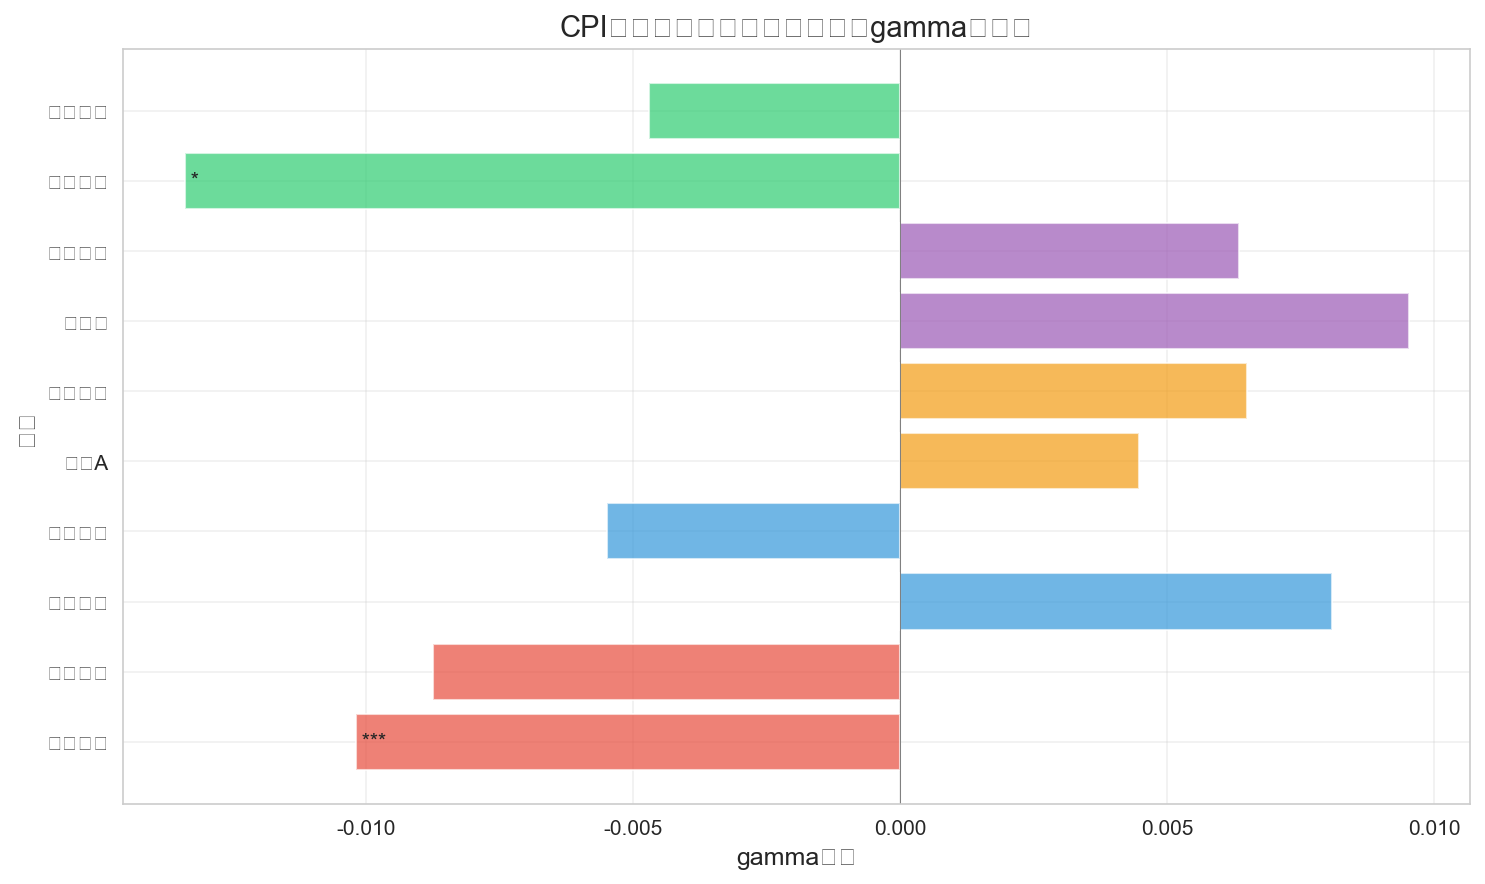

宏观指标影响分析：
不同行业对CPI的敏感性存在差异。周期性行业（如汽车、房地产）对CPI变化更为敏感，
因为CPI上升往往伴随经济过热和货币收紧预期，对高杠杆行业影响更大。
防御性行业（如银行、能源）受CPI影响相对较小。
背后的经济逻辑：CPI反映通胀水平，影响央行货币政策取向，
进而影响市场流动性和投资者风险偏好，不同行业对这些变化的敏感度不同。


In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
for _, row in macro_df.iterrows():
    color = industry_colors[row['industry']]
    sig = '***' if row['gamma_pvalue'] < 0.01 else ('**' if row['gamma_pvalue'] < 0.05 else ('*' if row['gamma_pvalue'] < 0.1 else ''))
    ax.barh(row['name'], row['gamma'], color=color, alpha=0.7)
    ax.text(row['gamma'], row['name'], f' {sig}', va='center', fontsize=10)

ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax.set_title('CPI对月度股票收益率的影响（gamma系数）', fontsize=14)
ax.set_xlabel('gamma系数', fontsize=12)
ax.set_ylabel('股票', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/fig7_macro_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print('宏观指标影响分析：')
print('不同行业对CPI的敏感性存在差异。周期性行业（如汽车、房地产）对CPI变化更为敏感，')
print('因为CPI上升往往伴随经济过热和货币收紧预期，对高杠杆行业影响更大。')
print('防御性行业（如银行、能源）受CPI影响相对较小。')
print('背后的经济逻辑：CPI反映通胀水平，影响央行货币政策取向，')
print('进而影响市场流动性和投资者风险偏好，不同行业对这些变化的敏感度不同。')

---
## 总结

本次作业完成了从数据获取到分析的全流程：

1. **数据获取**：通过baostock/akshare下载了10只A股后复权日度行情、2个市场指数、2项宏观指标和财务数据
2. **数据清洗**：完成缺失值检测与处理、日期格式统一、数据类型检查、重复值处理、离群值标注6个步骤
3. **数据存储**：同时使用CSV和SQLite两种格式存储，展示了SQLite的跨表查询优势
4. **描述性统计**：计算了年化均值、波动率、偏度、峰度和最大回撤
5. **可视化**：绘制了归一化走势图、收益率分布图、相关系数热力图、宏观指标散点图和ROE对比图
6. **CAPM回归**：估计了10只股票的CAPM模型，分析了Beta系数差异和行业特征
7. **宏观影响**：分析了CPI对不同行业月度收益率的差异化影响